In [ ]:
# libraries
import numpy as np
import pandas as pd
from numpy import array
import matplotlib.pyplot as plt

# from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [ ]:
columns = ['age','sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

# -- 1. #3  (age)         age in years
# -- 2. #4  (sex)         sex (1 = male; 0 = female)
# -- 3. #9  (cp)          cp: chest pain type (Value 1: typical angina; Value 2: atypical angina; Value 3: non-anginal pain; Value 4: asymptomatic)
# -- 4. #10 (trestbps)    resting blood pressure (in mm Hg on admission to the hospital)
# -- 5. #12 (chol)        serum cholestoral in mg/dl
# -- 6. #16 (fbs)         fasting blood sugar > 120 mg/dl  (1 = true; 0 = false)
# -- 7. #19 (restecg)     resting electrocardiographic results (Value 0: normal; Value 1: having ST-T wave abnormality (T wave inversions and/or ST
#                         elevation or depression of > 0.05 mV); Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria)
# -- 8. #32 (thalach)     maximum heart rate achieved
# -- 9. #38 (exang)       exercise induced angina (1 = yes; 0 = no)
# -- 10. #40 (oldpeak)    ST depression induced by exercise relative to rest
# -- 11. #41 (slope)      the slope of the peak exercise ST segment (Value 1: upsloping; Value 2: flat; Value 3: downsloping)
# -- 12. #44 (ca)         number of major vessels (0-3) colored by flourosopy
# -- 13. #51 (thal)       3 = normal; 6 = fixed defect; 7 = reversable defect
# -- 14. #58 (num)        diagnosis of heart disease (angiographic disease status) (Value 0: < 50% diameter narrowing; Value 1: > 50% diameter narrowing)
#                         (in any major vessel: attributes 59 through 68 are vessels)

In [ ]:
# Read the data in the CSV file using pandas
cleveland = pd.read_csv(r"..\data\heart_disease\processed.hungarian.data", sep=",", names=columns, na_values='?')


# Need to predict only absence (0) vs presence (1,2,3,4)
# Use np.where for element-wise conditional assignment; cant use if condition on panda df
cleveland['num'] = np.where(cleveland['num'] == 0, 0, 1)

# Check shape
print(cleveland.shape)
print(cleveland["num"].value_counts())
# print(cleveland)

(303, 14)
num
0    164
1    139
Name: count, dtype: int64



# Pre-Processing

1. Check for misisng values and either drop or impute
2. Categircal -> Numerical
3. Standardise / Normalise

In [ ]:
# Prints concise summary including count of non-null entries and data type of each column
cleveland.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [ ]:
# check for missing values
print("Number of missing values in each column =\n",cleveland.isnull().sum())
print("\nNumber of total missing values =",cleveland.isnull().sum().sum())

Number of missing values in each column =
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Number of total missing values = 6


In [ ]:
#impute missing values in ca and thal columns with median
cleveland['ca'] = cleveland['ca'].fillna(cleveland['ca'].median())
cleveland['thal'] = cleveland['thal'].fillna(cleveland['thal'].median())

# check for missing values
print("Number of missing values =",cleveland.isnull().sum().sum())

Number of missing values = 0


1. (age) - **Standardise**
2. (sex) - **do nothing, binary encoding works here**
3. (cp)  - **do one hot encoding**
4. (trestbps) - **Standardise**
5. (chol) - **Standardise**
6. (fbs)  - **do nothing, binary encoding works here**
7. (restecg) - **do one hot encoding**
8. (thalach) - **Standardise**
9. (exang)   - **do nothing, binary encoding works here**
10. (oldpeak) - **Standardise**
11. (slope)  - **do one hot encoding**
12. (ca) - **cardinal data, can leave as is**
13. (thal) - **do one hot encoding**
14. (num)  - **do nothing, binary encoding works here**

In [ ]:
# although all variables are numerical, some of them are categorical still like cp, restecg, slope, thal
# best to one hot encode these so that the model doesnt confuse them for numerical magnitudes
# binary variables can be left as is: sex, fbs, exang, num (converted to binary already in dataset)

cleveland['sex'] = cleveland['sex'].astype(int)
cleveland['fbs'] = cleveland['fbs'].astype(int)
cleveland['exang'] = cleveland['exang'].astype(int)
cleveland['ca'] = cleveland['ca'].astype(int)

# one hot encoding using pandas get dummies
cp = pd.get_dummies(cleveland['cp'], prefix='cp', dtype=int)
restecg = pd.get_dummies(cleveland['restecg'], prefix='restecg', dtype=int)
slope = pd.get_dummies(cleveland['slope'], prefix='slope', dtype=int)
thal = pd.get_dummies(cleveland['thal'], prefix='thal', dtype=int)

num = cleveland['num']

cleveland1 = cleveland.drop(['cp', 'restecg', 'slope', 'thal', 'num'], axis=1)
cleveland1 = pd.concat([cleveland1, cp, restecg, slope, thal, num], axis=1)

cleveland = cleveland1

cleveland.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          303 non-null    float64
 1   sex          303 non-null    int64  
 2   trestbps     303 non-null    float64
 3   chol         303 non-null    float64
 4   fbs          303 non-null    int64  
 5   thalach      303 non-null    float64
 6   exang        303 non-null    int64  
 7   oldpeak      303 non-null    float64
 8   ca           303 non-null    int64  
 9   cp_1.0       303 non-null    int64  
 10  cp_2.0       303 non-null    int64  
 11  cp_3.0       303 non-null    int64  
 12  cp_4.0       303 non-null    int64  
 13  restecg_0.0  303 non-null    int64  
 14  restecg_1.0  303 non-null    int64  
 15  restecg_2.0  303 non-null    int64  
 16  slope_1.0    303 non-null    int64  
 17  slope_2.0    303 non-null    int64  
 18  slope_3.0    303 non-null    int64  
 19  thal_3.0

In [ ]:
# check ranges of each attribute
print(cleveland.describe().T[["min", "max", "mean", "std"]])

# cleveland.hist(bins=25, figsize=(15,10))
# plt.show()

               min    max        mean        std
age           29.0   77.0   54.438944   9.038662
sex            0.0    1.0    0.679868   0.467299
trestbps      94.0  200.0  131.689769  17.599748
chol         126.0  564.0  246.693069  51.776918
fbs            0.0    1.0    0.148515   0.356198
thalach       71.0  202.0  149.607261  22.875003
exang          0.0    1.0    0.326733   0.469794
oldpeak        0.0    6.2    1.039604   1.161075
ca             0.0    3.0    0.663366   0.934375
cp_1.0         0.0    1.0    0.075908   0.265288
cp_2.0         0.0    1.0    0.165017   0.371809
cp_3.0         0.0    1.0    0.283828   0.451600
cp_4.0         0.0    1.0    0.475248   0.500213
restecg_0.0    0.0    1.0    0.498350   0.500824
restecg_1.0    0.0    1.0    0.013201   0.114325
restecg_2.0    0.0    1.0    0.488449   0.500693
slope_1.0      0.0    1.0    0.468647   0.499842
slope_2.0      0.0    1.0    0.462046   0.499382
slope_3.0      0.0    1.0    0.069307   0.254395
thal_3.0       0.0  

In [ ]:
# age, trestbps, chol, thalach, oldpeak are now the only continuous numeric variables left
# should scale them because their ranges are quite different
# usually standardising preferred for most models
# for neural networks, normalising preferred
# trees require no scaling at all
# for now, will standardise everything

num_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

cleveland[num_columns] = StandardScaler().fit_transform(cleveland[num_columns])

print(cleveland.describe().T[["min", "max", "mean", "std"]])


                  min       max          mean       std
age         -2.819115  2.500191 -1.465641e-18  1.001654
sex          0.000000  1.000000  6.798680e-01  0.467299
trestbps    -2.145037  3.887739  4.426236e-16  1.001654
chol        -2.334877  6.138485  2.345026e-16  1.001654
fbs          0.000000  1.000000  1.485149e-01  0.356198
thalach     -3.442067  2.294182 -1.172513e-16  1.001654
exang        0.000000  1.000000  3.267327e-01  0.469794
oldpeak     -0.896862  4.451851  2.345026e-17  1.001654
ca           0.000000  3.000000  6.633663e-01  0.934375
cp_1.0       0.000000  1.000000  7.590759e-02  0.265288
cp_2.0       0.000000  1.000000  1.650165e-01  0.371809
cp_3.0       0.000000  1.000000  2.838284e-01  0.451600
cp_4.0       0.000000  1.000000  4.752475e-01  0.500213
restecg_0.0  0.000000  1.000000  4.983498e-01  0.500824
restecg_1.0  0.000000  1.000000  1.320132e-02  0.114325
restecg_2.0  0.000000  1.000000  4.884488e-01  0.500693
slope_1.0    0.000000  1.000000  4.686469e-01  0

In [ ]:
X = cleveland.drop('num', axis=1)
y = cleveland['num']

In [ ]:
# function to plot metrics vs changing hyperparameters

def plot_metrics(df, x, title, log_scale=False):
    plt.figure(figsize=(8,5))

    # Always convert x column to string to handle mixed types (e.g., gamma)
    x_vals = df[x].astype(str)

    plt.plot(x_vals, df["Mean Accuracy"], marker='o', label="Accuracy")
    plt.plot(x_vals, df["Mean F1 Score"], marker='o', label="F1 Score")
    plt.plot(x_vals, df["Mean AUC ROC"], marker='o', label="AUC ROC")

    # Log scale only applies to true numeric x values
    if log_scale:
        # Only apply log scale if values are numeric
        try:
            numeric_vals = pd.to_numeric(df[x], errors='raise')
            plt.xscale("log")
        except:
            print("⚠ Log scale ignored: X axis contains non-numeric values.")

    plt.title(title)
    plt.xlabel(x)
    plt.ylabel("Metric Value")
    plt.legend()
    plt.grid(True)
    plt.show()


# Logistic Regression


In [ ]:
# defualt values for LogisticRegression in skikit

# class sklearn.linear_model.LogisticRegression(penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1,
# class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='deprecated', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None)

In [ ]:
# defining all hyperparameter values
penalties = ['none', 'l2', 'l1', 'elasticnet']
solvers = ['liblinear', 'lbfgs', 'saga']
reg_strengths = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
L1_ratios = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

In [ ]:
lg_solver = []
for solver in solvers:
    model = LogisticRegression(solver = solver, max_iter=10000)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    lg_solver.append({'Penalty': 'l2',
                'Solver': solver,
                'Regularisation Strength': 1.0,
                'L1 Ratio': 'None',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

lg_penalty = []
for penalty in penalties:
    if penalty == 'elasticnet':
        model = LogisticRegression(penalty = penalty, solver='saga', l1_ratio=0.5, max_iter=10000)
    elif penalty == 'none':
        model = LogisticRegression(penalty = None, solver='saga', max_iter=10000)
    else:
        model = LogisticRegression(penalty = penalty, solver='saga', max_iter=10000)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    lg_penalty.append({'Penalty': penalty,
              'Solver': 'saga',
              'Regularisation Strength': 1.0,
              'L1 Ratio': 0.5 if penalty == 'elasticnet' else 'None',
              'Mean Accuracy': scores['test_accuracy'].mean(),
              'Mean F1 Score' : scores['test_f1'].mean(),
              'Mean AUC ROC': scores['test_roc_auc'].mean()})

lg_C = []
for reg_strength in reg_strengths:
    model = LogisticRegression(C=reg_strength, max_iter=10000)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    lg_C.append({'Penalty': 'l2',
              'Solver': 'lbfgs',
              'Regularisation Strength': reg_strength,
              'L1 Ratio': 'None',
              'Mean Accuracy': scores['test_accuracy'].mean(),
              'Mean F1 Score' : scores['test_f1'].mean(),
              'Mean AUC ROC': scores['test_roc_auc'].mean()})


lg_l1ratio = []
for L1_ratio in L1_ratios:
    model = LogisticRegression(penalty = 'elasticnet',solver='saga',l1_ratio=L1_ratio, max_iter=10000)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    lg_l1ratio.append({'Penalty': 'elasticnet',
              'Solver': 'saga',
              'Regularisation Strength': 1.0,
              'L1 Ratio': L1_ratio,
              'Mean Accuracy': scores['test_accuracy'].mean(),
              'Mean F1 Score' : scores['test_f1'].mean(),
              'Mean AUC ROC': scores['test_roc_auc'].mean()})

In [ ]:
df_lg_solver = pd.DataFrame(lg_solver)
df_lg_penalty = pd.DataFrame(lg_penalty)
df_lg_C = pd.DataFrame(lg_C)
df_lg_l1ratio = pd.DataFrame(lg_l1ratio)

display(df_lg_solver)
print("\n\n")
display(df_lg_penalty)
print("\n\n")
display(df_lg_C)
print("\n\n")
display(df_lg_l1ratio)
print("\n\n")

lg_hp_solv_acc = (df_lg_solver['Mean Accuracy'].var())
lg_hp_pnlt_acc = (df_lg_penalty['Mean Accuracy'].var())
lg_hp_regs_acc = (df_lg_C['Mean Accuracy'].var())
lg_hp_l1ra_acc = (df_lg_l1ratio['Mean Accuracy'].var())

lg_hp_solv_f1 = (df_lg_solver['Mean F1 Score'].var())
lg_hp_pnlt_f1 = (df_lg_penalty['Mean F1 Score'].var())
lg_hp_regs_f1 = (df_lg_C['Mean F1 Score'].var())
lg_hp_l1ra_f1 = (df_lg_l1ratio['Mean F1 Score'].var())

lg_hp_solv_auc = (df_lg_solver['Mean AUC ROC'].var())
lg_hp_pnlt_auc = (df_lg_penalty['Mean AUC ROC'].var())
lg_hp_regs_auc = (df_lg_C['Mean AUC ROC'].var())
lg_hp_l1ra_auc = (df_lg_l1ratio['Mean AUC ROC'].var())

print("Solver (Accuracy): " + str(lg_hp_solv_acc))
print("Penalty (Accuracy): " + str(lg_hp_pnlt_acc))
print("Reg Strength (Accuracy): " + str(lg_hp_regs_acc))
print("L1 Ratio (Accuracy): " + str(lg_hp_l1ra_acc))
print("\n")
print("Solver (F1 Score): " + str(lg_hp_solv_f1))
print("Penalty (F1 Score): " + str(lg_hp_pnlt_f1))
print("Reg Strength (F1 Score): " + str(lg_hp_regs_f1))
print("L1 Ratio (F1 Score): " + str(lg_hp_l1ra_f1))
print("\n")
print("Solver (AUC): " + str(lg_hp_solv_auc))
print("Penalty (AUC): " + str(lg_hp_pnlt_auc))
print("Reg Strength (AUC): " + str(lg_hp_regs_auc))
print("L1 Ratio (AUC): " + str(lg_hp_l1ra_auc))

,Penalty,Solver,Regularisation Strength,L1 Ratio,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,l2,liblinear,1.0,None,0.828142,0.805781,0.912174
1,l2,lbfgs,1.0,None,0.828142,0.805781,0.913725
2,l2,saga,1.0,None,0.828142,0.805781,0.913509


,Penalty,Solver,Regularisation Strength,L1 Ratio,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,none,saga,1.0,None,0.818251,0.794311,0.908910
1,l2,saga,1.0,None,0.828142,0.805781,0.913509
2,l1,saga,1.0,None,0.815027,0.791390,0.912645
3,elasticnet,saga,1.0,0.5,0.824863,0.803092,0.912210


,Penalty,Solver,Regularisation Strength,L1 Ratio,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,l2,lbfgs,0.001,None,0.696230,0.518282,0.886684
1,l2,lbfgs,0.010,None,0.818361,0.781606,0.899020
2,l2,lbfgs,0.100,None,0.844645,0.820588,0.912239
3,l2,lbfgs,1.000,None,0.828142,0.805781,0.913725
4,l2,lbfgs,10.000,None,0.818251,0.794311,0.910447
5,l2,lbfgs,100.000,None,0.814973,0.791622,0.909133
6,l2,lbfgs,1000.000,None,0.811639,0.788799,0.908464


,Penalty,Solver,Regularisation Strength,L1 Ratio,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,elasticnet,saga,1.0,0.1,0.831475,0.808829,0.913285
1,elasticnet,saga,1.0,0.2,0.828197,0.806140,0.912852
2,elasticnet,saga,1.0,0.3,0.828197,0.806140,0.912635
3,elasticnet,saga,1.0,0.4,0.828197,0.806140,0.911987
4,elasticnet,saga,1.0,0.5,0.824863,0.803092,0.912210
5,elasticnet,saga,1.0,0.6,0.824863,0.803092,0.912218
6,elasticnet,saga,1.0,0.7,0.824863,0.803092,0.911993
7,elasticnet,saga,1.0,0.8,0.821585,0.799082,0.912645
8,elasticnet,saga,1.0,0.9,0.821585,0.799082,0.911996





Solver (Accuracy): 0.0
Penalty (Accuracy): 3.5952850189614596e-05
Reg Strength (Accuracy): 0.0024058065974755004
L1 Ratio (Accuracy): 1.0914860932777564e-05


Solver (F1 Score): 1.8488927466117464e-32
Penalty (F1 Score): 4.7372716723603996e-05
Reg Strength (F1 Score): 0.011269327078305939
L1 Ratio (F1 Score): 1.0963350827499914e-05


Solver (AUC): 7.060380846622052e-07
Penalty (AUC): 4.050315973454142e-06
Reg Strength (AUC): 9.255910287561598e-05
L1 Ratio (AUC): 2.0839242931973545e-07


In [ ]:
lg_summary = pd.DataFrame({
    "Hyperparameter": ["Solver", "Penalty", "C", "L1 Ratio"],
    "Var_Accuracy": [lg_hp_solv_acc, lg_hp_pnlt_acc, lg_hp_regs_acc, lg_hp_l1ra_acc],
    "Var_F1_Score": [lg_hp_solv_f1, lg_hp_pnlt_f1, lg_hp_regs_f1, lg_hp_l1ra_f1],
    "Var_AUC_ROC": [lg_hp_solv_auc, lg_hp_pnlt_auc, lg_hp_regs_auc, lg_hp_l1ra_auc]
})

display(lg_summary)

,Hyperparameter,Var_Accuracy,Var_F1_Score,Var_AUC_ROC
0,Solver,0.000000,1.848893e-32,7.060381e-07
1,Penalty,0.000036,4.737272e-05,4.050316e-06
2,C,0.002406,1.126933e-02,9.255910e-05
3,L1 Ratio,0.000011,1.096335e-05,2.083924e-07


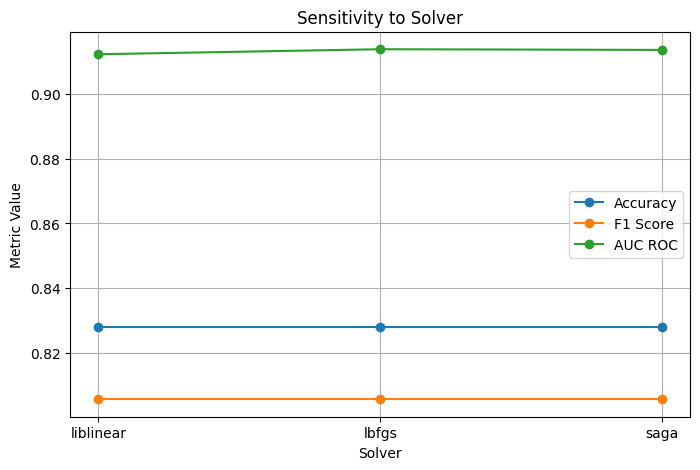

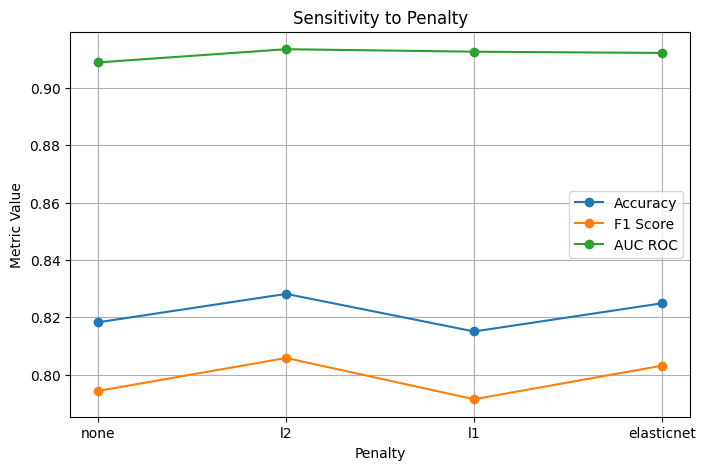

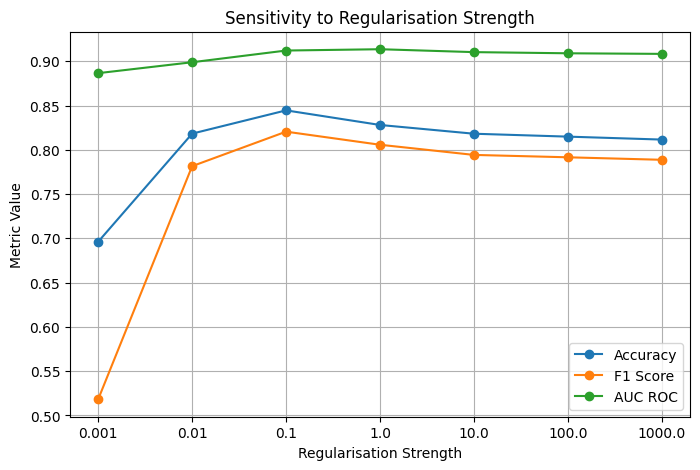

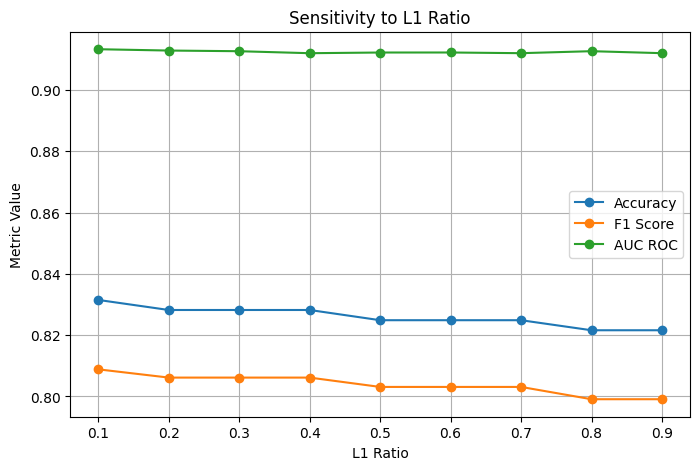

In [ ]:
plot_metrics(df_lg_solver, 'Solver', 'Sensitivity to Solver')
plot_metrics(df_lg_penalty, 'Penalty', 'Sensitivity to Penalty')
plot_metrics(df_lg_C, 'Regularisation Strength', 'Sensitivity to Regularisation Strength')
plot_metrics(df_lg_l1ratio, 'L1 Ratio', 'Sensitivity to L1 Ratio')

# K-Nearest Neighbours

In [ ]:
# defualt values for KNeighborsClassifier in skikit

# class sklearn.neighbors.KNeighborsClassifier(n_neighbors=5, *, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski',
# metric_params=None, n_jobs=None)

In [ ]:
# defining all hyperparameter values
n_neighbors = [i for i in range(1,32)]
weights = ['uniform','distance']
algorithms = ['auto', 'ball_tree', 'kd_tree', 'brute']
metric = ['euclidean', 'manhattan', 'minkowski','chebyshev','cosine']

In [ ]:
knn_kneighbours = []
for k in n_neighbors:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    knn_kneighbours.append({'N Neighbours': k,
                'Weight Metric': 'uniform',
                'Algorithm': 'auto',
                'Distance Metric': 'Euclidean',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})


knn_weightmetric = []
for w in weights:
    model = KNeighborsClassifier(weights=w)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    knn_weightmetric.append({'N Neighbours': 5,
                'Weight Metric': w,
                'Algorithm': 'auto',
                'Distance Metric': 'Euclidean',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

knn_algorithms = []
for a in algorithms:
    model = KNeighborsClassifier(algorithm=a)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    knn_algorithms.append({'N Neighbours': 5,
                'Weight Metric': 'uniform',
                'Algorithm': a,
                'Distance Metric': 'Euclidean',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

knn_distmetric = []
for d in metric:
    model = KNeighborsClassifier(metric=d)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    knn_distmetric.append({'N Neighbours': 5,
                'Weight Metric': 'uniform',
                'Algorithm': 'auto',
                'Distance Metric': d,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

In [ ]:
df_knn_kneighbours = pd.DataFrame(knn_kneighbours)
df_knn_weightmetric = pd.DataFrame(knn_weightmetric)
df_knn_algorithms = pd.DataFrame(knn_algorithms)
df_knn_distmetric = pd.DataFrame(knn_distmetric)

display(df_knn_kneighbours)
print("\n\n")
display(df_knn_weightmetric)
print("\n\n")
display(df_knn_algorithms)
print("\n\n")
display(df_knn_distmetric)
print("\n\n")

knn_hp_knei_acc = (df_knn_kneighbours['Mean Accuracy'].var())
knn_hp_weig_acc = (df_knn_weightmetric['Mean Accuracy'].var())
knn_hp_algo_acc = (df_knn_algorithms['Mean Accuracy'].var())
knn_hp_dist_acc = (df_knn_distmetric['Mean Accuracy'].var())

knn_hp_knei_f1 = (df_knn_kneighbours['Mean F1 Score'].var())
knn_hp_weig_f1 = (df_knn_weightmetric['Mean F1 Score'].var())
knn_hp_algo_f1 = (df_knn_algorithms['Mean F1 Score'].var())
knn_hp_dist_f1 = (df_knn_distmetric['Mean F1 Score'].var())

knn_hp_knei_auc = (df_knn_kneighbours['Mean AUC ROC'].var())
knn_hp_weig_auc = (df_knn_weightmetric['Mean AUC ROC'].var())
knn_hp_algo_auc = (df_knn_algorithms['Mean AUC ROC'].var())
knn_hp_dist_auc = (df_knn_distmetric['Mean AUC ROC'].var())

print("K Neighbours (Accuracy): " + str(knn_hp_knei_acc))
print("Weight Metric (Accuracy): " + str(knn_hp_weig_acc))
print("Algorithm (Accuracy): " + str(knn_hp_algo_acc))
print("Distance Metric (Accuracy): " + str(knn_hp_dist_acc))
print("\n")
print("K Neighbours (F1 Score): " + str(knn_hp_knei_f1))
print("Weight Metric (F1 Score): " + str(knn_hp_weig_f1))
print("Algorithm (F1 Score): " + str(knn_hp_algo_f1))
print("Distance Metric (F1 Score): " + str(knn_hp_dist_f1))
print("\n")
print("K Neighbours (AUC): " + str(knn_hp_knei_auc))
print("Weight Metric (AUC): " + str(knn_hp_weig_auc))
print("Algorithm (AUC): " + str(knn_hp_algo_auc))
print("Distance Metric (AUC): " + str(knn_hp_dist_auc))

,N Neighbours,Weight Metric,Algorithm,Distance Metric,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,1,uniform,auto,Euclidean,0.749071,0.725017,0.747111
1,2,uniform,auto,Euclidean,0.765574,0.700065,0.833010
2,3,uniform,auto,Euclidean,0.805082,0.794538,0.851448
3,4,uniform,auto,Euclidean,0.811585,0.776088,0.863133
4,5,uniform,auto,Euclidean,0.818306,0.797697,0.871229
5,6,uniform,auto,Euclidean,0.801694,0.765819,0.873091
6,7,uniform,auto,Euclidean,0.811858,0.789187,0.880436
7,8,uniform,auto,Euclidean,0.825027,0.792984,0.895766
8,9,uniform,auto,Euclidean,0.815027,0.786964,0.892350
9,10,uniform,auto,Euclidean,0.814973,0.777029,0.891593


,N Neighbours,Weight Metric,Algorithm,Distance Metric,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,5,uniform,auto,Euclidean,0.818306,0.797697,0.871229
1,5,distance,auto,Euclidean,0.818306,0.797697,0.871805


,N Neighbours,Weight Metric,Algorithm,Distance Metric,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,5,uniform,auto,Euclidean,0.818306,0.797697,0.871229
1,5,uniform,ball_tree,Euclidean,0.818306,0.797697,0.871229
2,5,uniform,kd_tree,Euclidean,0.818306,0.797697,0.871229
3,5,uniform,brute,Euclidean,0.818306,0.797697,0.871229


,N Neighbours,Weight Metric,Algorithm,Distance Metric,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,5,uniform,auto,euclidean,0.818306,0.797697,0.871229
1,5,uniform,auto,manhattan,0.815246,0.797293,0.874518
2,5,uniform,auto,minkowski,0.818306,0.797697,0.871229
3,5,uniform,auto,chebyshev,0.702787,0.654943,0.755821
4,5,uniform,auto,cosine,0.818689,0.810121,0.872265





K Neighbours (Accuracy): 0.00022554268341040896
Weight Metric (Accuracy): 0.0
Algorithm (Accuracy): 0.0
Distance Metric (Accuracy): 0.0026400214995968823


K Neighbours (F1 Score): 0.0003637208477458575
Weight Metric (F1 Score): 0.0
Algorithm (F1 Score): 0.0
Distance Metric (F1 Score): 0.004278757307414101


K Neighbours (AUC): 0.0008071727742368547
Weight Metric (AUC): 1.6585803309948946e-07
Algorithm (AUC): 0.0
Distance Metric (AUC): 0.002715754179309542


In [ ]:
knn_summary = pd.DataFrame({
    "Hyperparameter": ["N Neighbours","Weight Metric","Algorithm","Distance Metric"],
    "Var_Accuracy": [knn_hp_knei_acc, knn_hp_weig_acc, knn_hp_algo_acc, knn_hp_dist_acc],
    "Var_F1_Score": [knn_hp_knei_f1, knn_hp_weig_f1, knn_hp_algo_f1, knn_hp_dist_f1],
    "Var_AUC_ROC": [knn_hp_knei_auc, knn_hp_weig_auc, knn_hp_algo_auc, knn_hp_dist_auc]
})

display(knn_summary)

,Hyperparameter,Var_Accuracy,Var_F1_Score,Var_AUC_ROC
0,N Neighbours,0.000226,0.000364,8.071728e-04
1,Weight Metric,0.000000,0.000000,1.658580e-07
2,Algorithm,0.000000,0.000000,0.000000e+00
3,Distance Metric,0.002640,0.004279,2.715754e-03


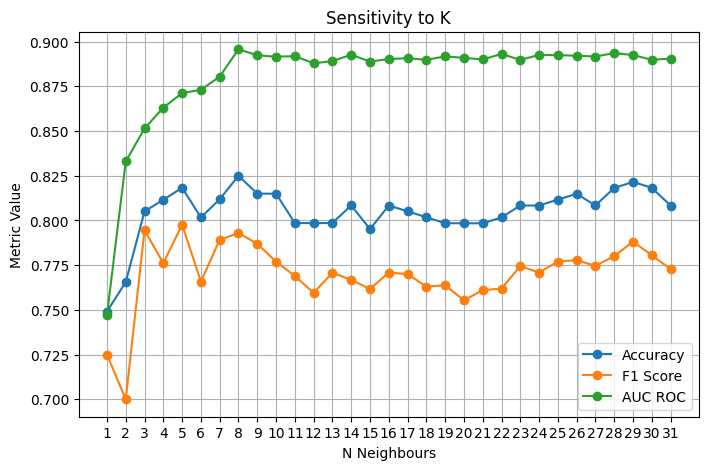

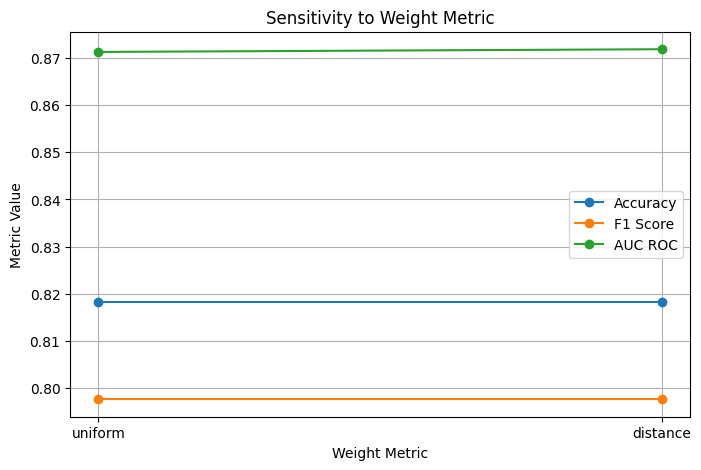

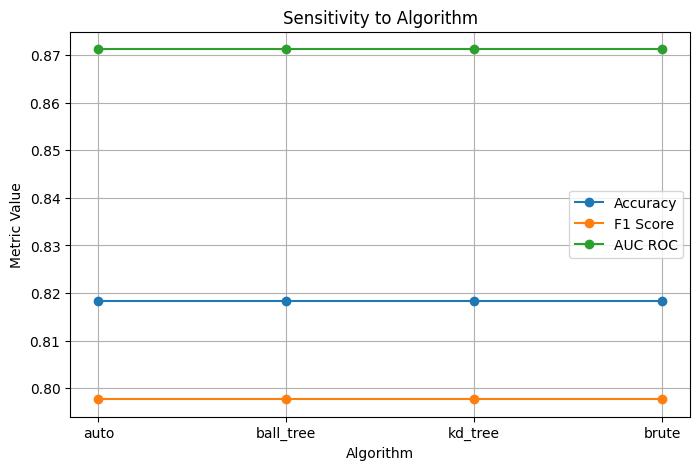

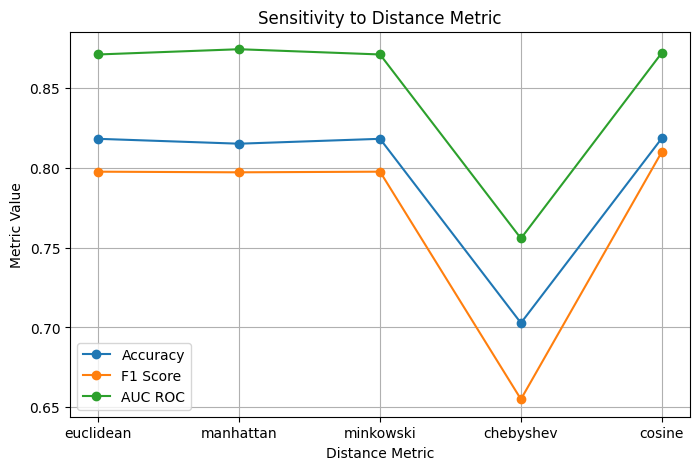

In [ ]:
plot_metrics(df_knn_kneighbours, "N Neighbours", "Sensitivity to K")
plot_metrics(df_knn_weightmetric, "Weight Metric", "Sensitivity to Weight Metric")
plot_metrics(df_knn_algorithms, "Algorithm", "Sensitivity to Algorithm")
plot_metrics(df_knn_distmetric, "Distance Metric", "Sensitivity to Distance Metric")

# Decision Tree

In [ ]:
# defualt values for DecisionTreeClassifier in skikit

# class sklearn.tree.DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1,
# min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None,
# ccp_alpha=0.0, monotonic_cst=None)

In [ ]:
criteria = ['gini','entropy','log_loss']
max_depths = [None,2,3,5,10,15,20]
min_samples_splits = [2,5,10,15,20]
min_samples_leafs = [1,2,5,8,10]
max_features = [None, 'sqrt', 'log2']

In [ ]:
dt_criteria = []
for c in criteria:
    model = DecisionTreeClassifier(criterion=c)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    dt_criteria.append({'Criterion': c,
                'Max Depth': 'none',
                'Min Samples Split': 2,
                'Min Samples Leaf': 1,
                'Max Features' : 'none',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

dt_maxdepth = []
for d in max_depths:
    model = DecisionTreeClassifier(criterion='entropy',max_depth=d)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    dt_maxdepth.append({'Criterion': 'entropy',
                'Max Depth': 'none' if d == None else d,
                'Min Samples Split': 2,
                'Min Samples Leaf': 1,
                'Max Features' : 'none',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

dt_minsamplesplit = []
for s in min_samples_splits:
    model = DecisionTreeClassifier(criterion='entropy',min_samples_split=s)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    dt_minsamplesplit.append({'Criterion': 'entropy',
                'Max Depth': 'none',
                'Min Samples Split': s,
                'Min Samples Leaf': 1,
                'Max Features' : 'none',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

dt_minsamplesleaf = []
for l in min_samples_leafs:
    model = DecisionTreeClassifier(criterion='entropy',min_samples_leaf=l)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    dt_minsamplesleaf.append({'Criterion': 'entropy',
                'Max Depth': 'none',
                'Min Samples Split': 2,
                'Min Samples Leaf': l,
                'Max Features' : 'none',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

dt_maxfeatures = []
for f in max_features:
    model = DecisionTreeClassifier(criterion='entropy',max_features=f)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    dt_maxfeatures.append({'Criterion': 'entropy',
                'Max Depth': 'none',
                'Min Samples Split': 2,
                'Min Samples Leaf': 1,
                'Max Features' : 'none' if f == None else f,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

In [ ]:
df_dt_criteria = pd.DataFrame(dt_criteria)
df_dt_maxdepth = pd.DataFrame(dt_maxdepth)
df_dt_minsamplesplit = pd.DataFrame(dt_minsamplesplit)
df_dt_minsamplesleaf = pd.DataFrame(dt_minsamplesleaf)
df_dt_maxfeatures = pd.DataFrame(dt_maxfeatures)

display(df_dt_criteria)
print("\n\n")
display(df_dt_maxdepth)
print("\n\n")
display(df_dt_minsamplesplit)
print("\n\n")
display(df_dt_minsamplesleaf)
print("\n\n")
display(df_dt_maxfeatures)
print("\n\n")

dt_hp_crit_acc = (df_dt_criteria['Mean Accuracy'].var())
dt_hp_maxd_acc = (df_dt_maxdepth['Mean Accuracy'].var())
dt_hp_split_acc = (df_dt_minsamplesplit['Mean Accuracy'].var())
dt_hp_leaf_acc = (df_dt_minsamplesleaf['Mean Accuracy'].var())
dt_hp_maxf_acc = (df_dt_maxfeatures['Mean Accuracy'].var())

dt_hp_crit_f1 = (df_dt_criteria['Mean F1 Score'].var())
dt_hp_maxd_f1 = (df_dt_maxdepth['Mean F1 Score'].var())
dt_hp_split_f1 = (df_dt_minsamplesplit['Mean F1 Score'].var())
dt_hp_leaf_f1 = (df_dt_minsamplesleaf['Mean F1 Score'].var())
dt_hp_maxf_f1 = (df_dt_maxfeatures['Mean F1 Score'].var())

dt_hp_crit_auc = (df_dt_criteria['Mean AUC ROC'].var())
dt_hp_maxd_auc = (df_dt_maxdepth['Mean AUC ROC'].var())
dt_hp_split_auc = (df_dt_minsamplesplit['Mean AUC ROC'].var())
dt_hp_leaf_auc = (df_dt_minsamplesleaf['Mean AUC ROC'].var())
dt_hp_maxf_auc = (df_dt_maxfeatures['Mean AUC ROC'].var())

print("Criteria (Accuracy) : " + str(dt_hp_crit_acc))
print("Max Depth (Accuracy) : " + str(dt_hp_maxd_acc))
print("Min Samples Split (Accuracy) : " + str(dt_hp_split_acc))
print("Min Samples Leaf (Accuracy) : " + str(dt_hp_leaf_acc))
print("Max Features (Accuracy) : " + str(dt_hp_maxf_acc))
print("\n")
print("Criteria (F1 Score) : " + str(dt_hp_crit_f1))
print("Max Depth (F1 Score) : " + str(dt_hp_maxd_f1))
print("Min Samples Split (F1 Score) : " + str(dt_hp_split_f1))
print("Min Samples Leaf (F1 Score) : " + str(dt_hp_leaf_f1))
print("Max Features (F1 Score) : " + str(dt_hp_maxf_f1))
print("\n")
print("Criteria (AUC) : " + str(dt_hp_crit_auc))
print("Max Depth (AUC) : " + str(dt_hp_maxd_auc))
print("Min Samples Split (AUC) : " + str(dt_hp_split_auc))
print("Min Samples Leaf (AUC) : " + str(dt_hp_leaf_auc))
print("Max Features (AUC) : " + str(dt_hp_maxf_auc))

,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Max Features,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,gini,none,2,1,none,0.745574,0.715434,0.743131
1,entropy,none,2,1,none,0.749016,0.725111,0.747300
2,log_loss,none,2,1,none,0.735847,0.708752,0.734279


,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Max Features,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,entropy,none,2,1,none,0.732568,0.709062,0.731286
1,entropy,2,2,1,none,0.732459,0.667747,0.804928
2,entropy,3,2,1,none,0.784973,0.749559,0.824733
3,entropy,5,2,1,none,0.745683,0.706929,0.772693
4,entropy,10,2,1,none,0.742514,0.727172,0.743385
5,entropy,15,2,1,none,0.745738,0.726038,0.745068
6,entropy,20,2,1,none,0.739126,0.719131,0.738561


,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Max Features,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,entropy,none,2,1,none,0.725956,0.706149,0.725358
1,entropy,none,5,1,none,0.745738,0.719666,0.750976
2,entropy,none,10,1,none,0.739016,0.712337,0.777937
3,entropy,none,15,1,none,0.729126,0.699917,0.788131
4,entropy,none,20,1,none,0.781639,0.737073,0.794551


,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Max Features,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,entropy,none,2,1,none,0.735792,0.716015,0.735531
1,entropy,none,2,2,none,0.752295,0.719090,0.751814
2,entropy,none,2,5,none,0.761967,0.735224,0.804135
3,entropy,none,2,8,none,0.785027,0.752393,0.846230
4,entropy,none,2,10,none,0.808251,0.775325,0.850625


,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Max Features,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,entropy,none,2,1,none,0.742404,0.722079,0.742133
1,entropy,none,2,1,sqrt,0.702951,0.675209,0.701296
2,entropy,none,2,1,log2,0.745683,0.720135,0.743747





Criteria (Accuracy) : 4.664914847661476e-05
Max Depth (Accuracy) : 0.0003236762888738166
Min Samples Split (Accuracy) : 0.0004977404520887444
Min Samples Leaf (Accuracy) : 0.0008070629161814338
Max Features (Accuracy) : 0.000565562821623022


Criteria (F1 Score) : 6.765695514698875e-05
Max Depth (F1 Score) : 0.0006357695271807656
Min Samples Split (F1 Score) : 0.00020547582845799073
Min Samples Leaf (F1 Score) : 0.0006089962850643201
Max Features (F1 Score) : 0.0007031643729667095


Criteria (AUC) : 4.421736518716897e-05
Max Depth (AUC) : 0.0013195077342710384
Min Samples Split (AUC) : 0.0008288127545145276
Min Samples Leaf (AUC) : 0.002792060131112409
Max Features (AUC) : 0.000578729108276817


In [ ]:
dt_summary = pd.DataFrame({
    "Hyperparameter": ["Criterion", "Max Depth", "Min Samples Split", "Min Samples Leaf", "Max Features"],
    "Var_Accuracy": [dt_hp_crit_acc, dt_hp_maxd_acc, dt_hp_split_acc, dt_hp_leaf_acc, dt_hp_maxf_acc],
    "Var_F1_Score": [dt_hp_crit_f1, dt_hp_maxd_f1, dt_hp_split_f1, dt_hp_leaf_f1, dt_hp_maxf_f1],
    "Var_AUC_ROC": [dt_hp_crit_auc, dt_hp_maxd_auc, dt_hp_split_auc, dt_hp_leaf_auc, dt_hp_maxf_auc]
})

display(dt_summary)

,Hyperparameter,Var_Accuracy,Var_F1_Score,Var_AUC_ROC
0,Criterion,0.000047,0.000068,0.000044
1,Max Depth,0.000324,0.000636,0.001320
2,Min Samples Split,0.000498,0.000205,0.000829
3,Min Samples Leaf,0.000807,0.000609,0.002792
4,Max Features,0.000566,0.000703,0.000579


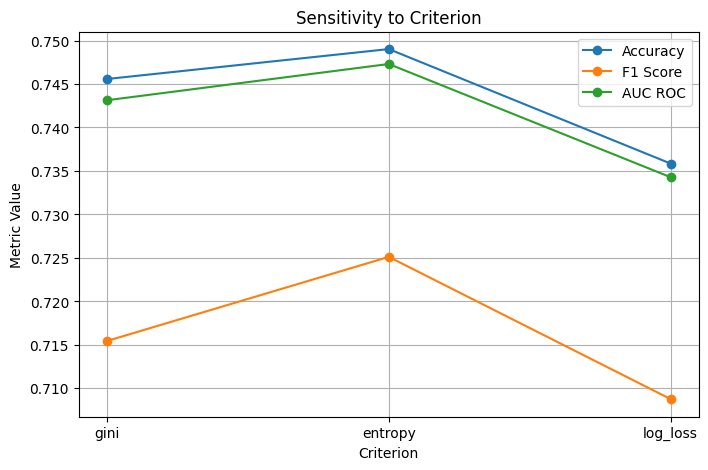

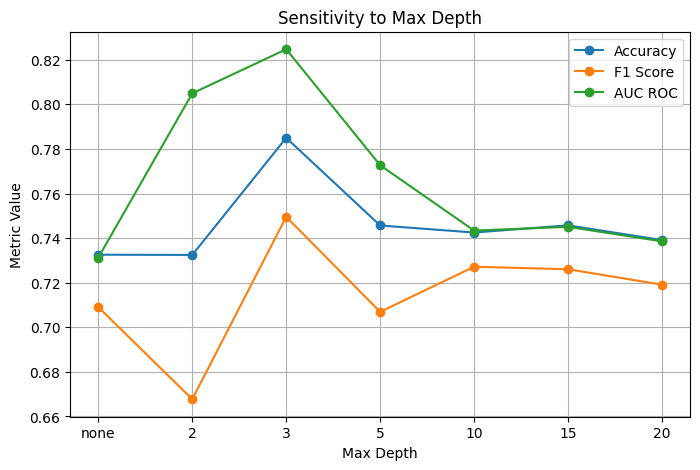

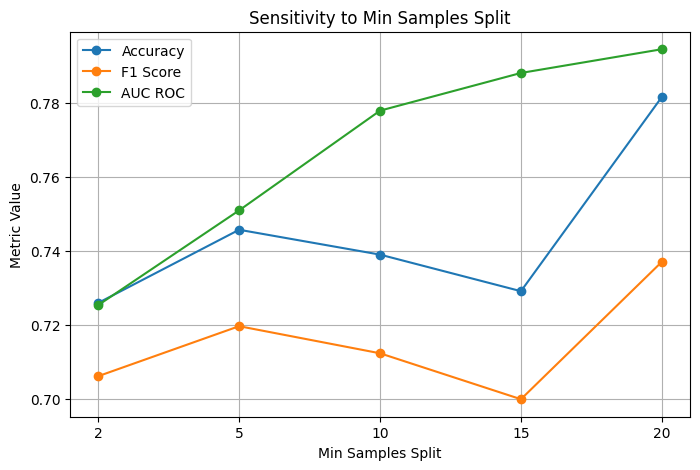

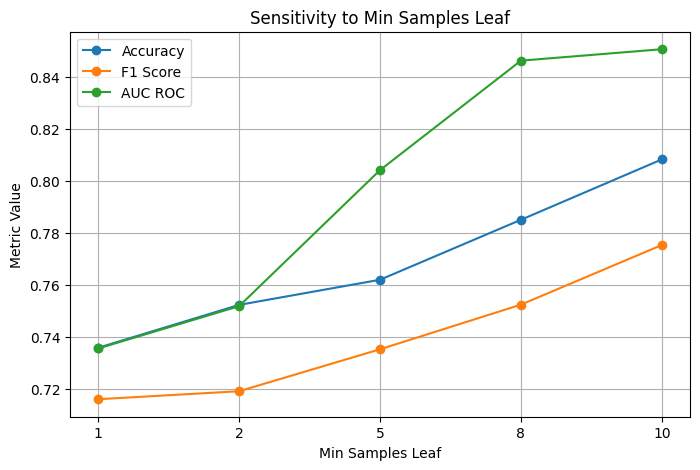

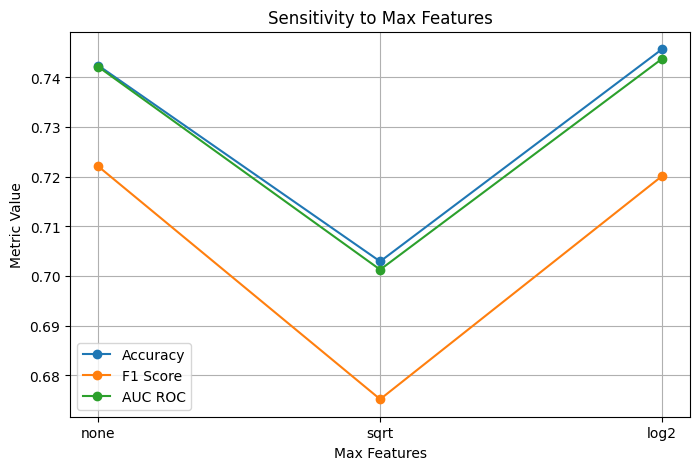

In [ ]:
plot_metrics(df_dt_criteria, "Criterion", "Sensitivity to Criterion")
plot_metrics(df_dt_maxdepth, "Max Depth", "Sensitivity to Max Depth")
plot_metrics(df_dt_minsamplesplit, "Min Samples Split", "Sensitivity to Min Samples Split")
plot_metrics(df_dt_minsamplesleaf, "Min Samples Leaf", "Sensitivity to Min Samples Leaf")
plot_metrics(df_dt_maxfeatures, "Max Features", "Sensitivity to Max Features")

# Support Vector Machine

In [ ]:
# defualt values for SVC in scikit

# class sklearn.svm.SVC(*, C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False,
# tol=0.001, cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr',
# break_ties=False, random_state=None)

In [ ]:
# defining all hyperparameter values
C_vals = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
kernel = ['linear', 'poly', 'rbf', 'sigmoid']
degree_for_poly = [2, 3, 4, 5]
gamma = ['scale', 'auto', 0.001, 0.01, 0.1, 1]

In [ ]:
svm_C = []
for c in C_vals:
    model = SVC(C=c, probability=True)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    svm_C.append({'C': c,
                'Kernel' : 'rbf',
                'Degree' : 'None',
                'Gamma' : 'scale',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

svm_kernel = []
for k in kernel:
    model = SVC(kernel=k, probability=True)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    svm_kernel.append({'C': 1.0,
                'Kernel': k,
                'Degree' : 3 if k == 'poly' else 'None',
                'Gamma' : 'scale',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

svm_degree_for_poly = []
for d in degree_for_poly:
    model = SVC(kernel='poly', degree=d, probability=True)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    svm_degree_for_poly.append({'C': 1.0,
                'Kernel': 'poly',
                'Degree' : d,
                'Gamma' : 'scale',
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

svm_gamma = []
for g in gamma:
    model = SVC(gamma=g, probability=True)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    svm_gamma.append({'C': 1.0,
                'Kernel': 'rbf',
                'Degree' : 'None',
                'Gamma' : g,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

In [ ]:
df_svm_C = pd.DataFrame(svm_C)
df_svm_kernel = pd.DataFrame(svm_kernel)
df_svm_degree = pd.DataFrame(svm_degree_for_poly)
df_svm_gamma = pd.DataFrame(svm_gamma)

display(df_svm_C)
print("\n\n")
display(df_svm_kernel)
print("\n\n")
display(df_svm_degree)
print("\n\n")
display(df_svm_gamma)
print("\n\n")


svm_hp_cval_acc = (df_svm_C['Mean Accuracy'].var())
svm_hp_kern_acc = (df_svm_kernel['Mean Accuracy'].var())
svm_hp_degr_acc = (df_svm_degree['Mean Accuracy'].var())
svm_hp_gamm_acc = (df_svm_gamma['Mean Accuracy'].var())

svm_hp_cval_f1 = (df_svm_C['Mean F1 Score'].var())
svm_hp_kern_f1 = (df_svm_kernel['Mean F1 Score'].var())
svm_hp_degr_f1 = (df_svm_degree['Mean F1 Score'].var())
svm_hp_gamm_f1 = (df_svm_gamma['Mean F1 Score'].var())

svm_hp_cval_auc = (df_svm_C['Mean AUC ROC'].var())
svm_hp_kern_auc = (df_svm_kernel['Mean AUC ROC'].var())
svm_hp_degr_auc = (df_svm_degree['Mean AUC ROC'].var())
svm_hp_gamm_auc = (df_svm_gamma['Mean AUC ROC'].var())

print("C (Accuracy) : " + str(svm_hp_cval_acc))
print("Kernel (Accuracy) : " + str(svm_hp_kern_acc))
print("Degree for Poly Kernel (Accuracy) : " + str(svm_hp_degr_acc))
print("Gamma (Accuracy) : " + str(svm_hp_gamm_acc))
print("\n")
print("C (F1 Score) : " + str(svm_hp_cval_f1))
print("Kernel (F1 Score) : " + str(svm_hp_kern_f1))
print("Degree for Poly Kernel (F1 Score) : " + str(svm_hp_degr_f1))
print("Gamma (F1 Score) : " + str(svm_hp_gamm_f1))
print("\n")
print("C (AUC) : " + str(svm_hp_cval_auc))
print("Kernel (AUC) : " + str(svm_hp_kern_auc))
print("Degree for Poly Kernel (AUC) : " + str(svm_hp_degr_auc))
print("Gamma (AUC) : " + str(svm_hp_gamm_auc))
print("\n")

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,0.001,rbf,None,scale,0.541257,0.000000,0.890212
1,0.010,rbf,None,scale,0.541257,0.000000,0.890212
2,0.100,rbf,None,scale,0.815137,0.785715,0.893516
3,1.000,rbf,None,scale,0.818251,0.794107,0.895948
4,10.000,rbf,None,scale,0.798415,0.781660,0.858094
5,100.000,rbf,None,scale,0.801639,0.782717,0.850710
6,1000.000,rbf,None,scale,0.801639,0.782717,0.850710


,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,1.0,linear,None,scale,0.818306,0.795489,0.904972
1,1.0,poly,3,scale,0.798470,0.754771,0.896335
2,1.0,rbf,None,scale,0.818251,0.794107,0.895948
3,1.0,sigmoid,None,scale,0.838197,0.822615,0.908663


,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,1.0,poly,2,scale,0.828251,0.794860,0.904934
1,1.0,poly,3,scale,0.798470,0.754771,0.896335
2,1.0,poly,4,scale,0.781749,0.722785,0.884392
3,1.0,poly,5,scale,0.745410,0.652381,0.876538


,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,1.0,rbf,None,scale,0.818251,0.794107,0.895948
1,1.0,rbf,None,auto,0.841366,0.815180,0.902387
2,1.0,rbf,None,0.001,0.778634,0.695008,0.891582
3,1.0,rbf,None,0.01,0.851311,0.824560,0.910303
4,1.0,rbf,None,0.1,0.818251,0.794107,0.895739
5,1.0,rbf,None,1,0.643333,0.403250,0.815359





C (Accuracy) : 0.01687021950349014
Kernel (Accuracy) : 0.0002630376143410274
Degree for Poly Kernel (Accuracy) : 0.0011939701593558073
Gamma (Accuracy) : 0.005922688644032373


C (F1 Score) : 0.1468808128134541
Kernel (F1 Score) : 0.0007798748987768968
Degree for Poly Kernel (F1 Score) : 0.0036304711137721372
Gamma (F1 Score) : 0.026384815526425954


C (AUC) : 0.00045125894250807257
Kernel (AUC) : 4.028863786626016e-05
Degree for Poly Kernel (AUC) : 0.0001582066699640049
Gamma (AUC) : 0.0012141205812404266




In [ ]:
svm_summary = pd.DataFrame({
    "Hyperparameter": ["C Value","Kernel","Degree for Polynomial Kernel","Gamma"],
    "Var_Accuracy": [svm_hp_cval_acc, svm_hp_kern_acc, svm_hp_degr_acc, svm_hp_gamm_acc],
    "Var_F1_Score": [svm_hp_cval_f1, svm_hp_kern_f1, svm_hp_degr_f1, svm_hp_gamm_f1],
    "Var_AUC_ROC": [svm_hp_cval_auc, svm_hp_kern_auc, svm_hp_degr_auc, svm_hp_gamm_auc]
})

display(svm_summary)

,Hyperparameter,Var_Accuracy,Var_F1_Score,Var_AUC_ROC
0,C Value,0.016870,0.146881,0.000451
1,Kernel,0.000263,0.000780,0.000040
2,Degree for Polynomial Kernel,0.001194,0.003630,0.000158
3,Gamma,0.005923,0.026385,0.001214


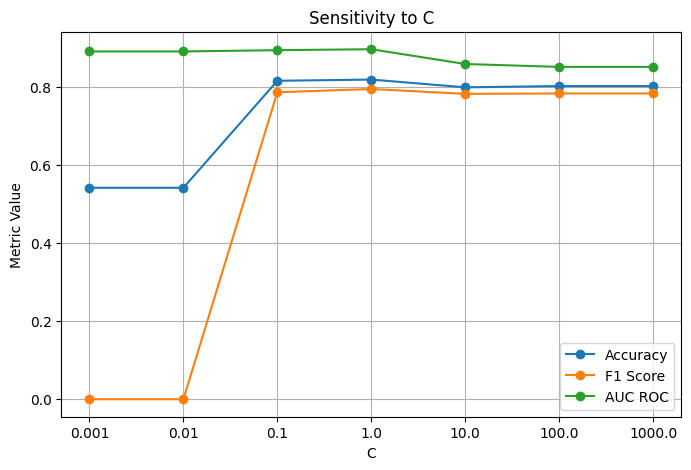

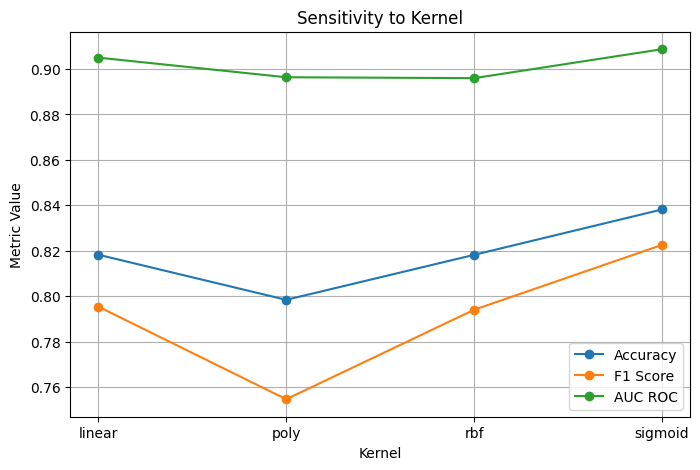

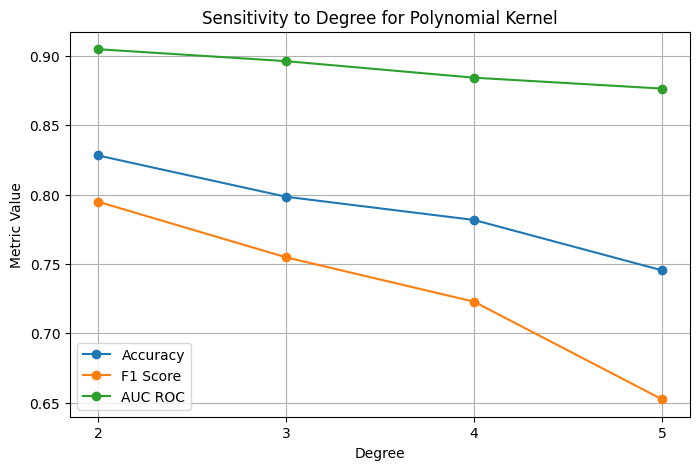

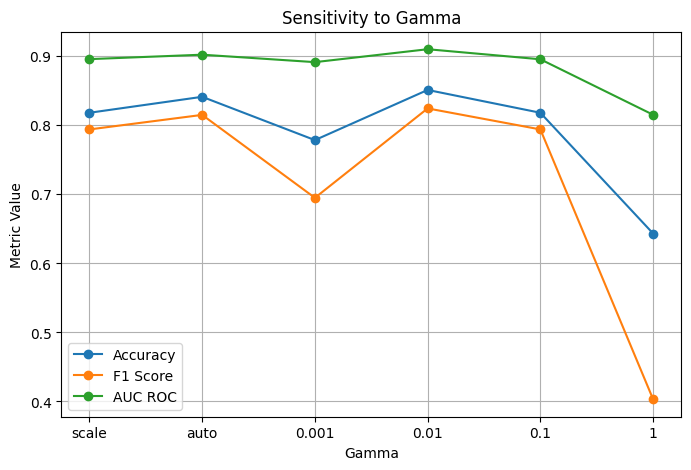

In [ ]:
plot_metrics(df_svm_C, "C", "Sensitivity to C")
plot_metrics(df_svm_kernel, "Kernel", "Sensitivity to Kernel")
plot_metrics(df_svm_degree, "Degree", "Sensitivity to Degree for Polynomial Kernel")
plot_metrics(df_svm_gamma, "Gamma", "Sensitivity to Gamma")

# Neural Network (MLP)

In [ ]:
# defualt values for MLP in scikit

# class sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(100,), activation='relu', *, solver='adam',
# alpha=0.0001, batch_size='auto', learning_rate='constant', learning_rate_init=0.001, power_t=0.5, max_iter=200,
# shuffle=True, random_state=None, tol=0.0001, verbose=False, warm_start=False, momentum=0.9, nesterovs_momentum=True,
# early_stopping=False, validation_fraction=0.1, beta_1=0.9, beta_2=0.999, epsilon=1e-08, n_iter_no_change=10, max_fun=15000)

In [ ]:
# defining all hyperparameter values

hidden_layer_sizes = [(10,),(50,),(100,),(10, 10),(50, 50),(100, 50)]
activation = ['identity', 'logistic', 'tanh', 'relu']
alphas = [0.0001, 0.001, 0.01, 0.1,1, 10, 100, 1000]
learning_rate = ['constant', 'invscaling', 'adaptive'] # only if solver is sgd
learning_rate_init = [0.0001, 0.001, 0.01, 0.1]

In [ ]:
mlp_hidden = []
for h in hidden_layer_sizes:
    # had to increase max_iter by A LOT and solver lbfgs is just faster for smaller datasets like iris
    model = MLPClassifier(hidden_layer_sizes=h, solver='lbfgs', max_iter=3000)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    mlp_hidden.append({'Hidden Layer Sizes': h,
                'Activation' : 'relu',
                'Alpha' : 0.0001,
                'Learning Rate' : 'constant',
                'Learning Rate Init' : 0.001,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

mlp_activation = []
for a in activation:
    model = MLPClassifier(activation=a, max_iter=3000)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    mlp_activation.append({'Hidden Layer Sizes': (100,),
                'Activation' : a,
                'Alpha' : 0.0001,
                'Learning Rate' : 'constant',
                'Learning Rate Init' : 0.001,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

mlp_alphas = []
for a in alphas:
    model = MLPClassifier(alpha=a, max_iter=3000)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    mlp_alphas.append({'Hidden Layer Sizes': (100,),
                'Activation' : 'relu',
                'Alpha' : a,
                'Learning Rate' : 'constant',
                'Learning Rate Init' : 0.001,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

mlp_learning_rate = []
for l in learning_rate:
    model = MLPClassifier(learning_rate=l, solver='sgd', max_iter=3000)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    mlp_learning_rate.append({'Hidden Layer Sizes': (100,),
                'Activation' : 'relu',
                'Alpha' : 0.0001,
                'Learning Rate' : l,
                'Learning Rate Init' : 0.001,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

mlp_learning_rate_init = []
for l in learning_rate_init:
    model = MLPClassifier(learning_rate_init=l, max_iter=3000)
    scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)
    mlp_learning_rate_init.append({'Hidden Layer Sizes': (100,),
                'Activation' : 'relu',
                'Alpha' : 0.0001,
                'Learning Rate' : 'constant',
                'Learning Rate Init' : l,
                'Mean Accuracy': scores['test_accuracy'].mean(),
                'Mean F1 Score' : scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_roc_auc'].mean()})

In [ ]:
df_mlp_hidden = pd.DataFrame(mlp_hidden)
df_mlp_activation = pd.DataFrame(mlp_activation)
df_mlp_alpha = pd.DataFrame(mlp_alphas)
df_mlp_learning_rate = pd.DataFrame(mlp_learning_rate)
df_mlp_learning_rate_init = pd.DataFrame(mlp_learning_rate_init)

display(df_mlp_hidden)
print("\n\n")
display(df_mlp_activation)
print("\n\n")
display(df_mlp_alpha)
print("\n\n")
display(df_mlp_learning_rate)
print("\n\n")
display(df_mlp_learning_rate_init)
print("\n\n")


mlp_hp_hidd_acc = (df_mlp_hidden['Mean Accuracy'].var())
mlp_hp_acti_acc = (df_mlp_activation['Mean Accuracy'].var())
mlp_hp_alph_acc = (df_mlp_alpha['Mean Accuracy'].var())
mlp_hp_lear_acc = (df_mlp_learning_rate['Mean Accuracy'].var())
mlp_hp_inlr_acc = (df_mlp_learning_rate_init['Mean Accuracy'].var())

mlp_hp_hidd_f1 = (df_mlp_hidden['Mean F1 Score'].var())
mlp_hp_acti_f1 = (df_mlp_activation['Mean F1 Score'].var())
mlp_hp_alph_f1 = (df_mlp_alpha['Mean F1 Score'].var())
mlp_hp_lear_f1 = (df_mlp_learning_rate['Mean F1 Score'].var())
mlp_hp_inlr_f1 = (df_mlp_learning_rate_init['Mean F1 Score'].var())

mlp_hp_hidd_auc = (df_mlp_hidden['Mean AUC ROC'].var())
mlp_hp_acti_auc = (df_mlp_activation['Mean AUC ROC'].var())
mlp_hp_alph_auc = (df_mlp_alpha['Mean AUC ROC'].var())
mlp_hp_lear_auc = (df_mlp_learning_rate['Mean AUC ROC'].var())
mlp_hp_inlr_auc = (df_mlp_learning_rate_init['Mean AUC ROC'].var())

print("Hidden Layer Sizes (Accuracy) : " + str(mlp_hp_hidd_acc))
print("Activation Function (Accuracy) : " + str(mlp_hp_acti_acc))
print("Alpha (Accuracy) : " + str(mlp_hp_alph_acc))
print("Learning Rate (Accuracy) : " + str(mlp_hp_lear_acc))
print("Learning Rate Init (Accuracy) : " + str(mlp_hp_inlr_acc))
print("\n")
print("Hidden Layer Sizes (F1 Score) : " + str(mlp_hp_hidd_f1))
print("Activation Function (F1 Score) : " + str(mlp_hp_acti_f1))
print("Alpha (F1 Score) : " + str(mlp_hp_alph_f1))
print("Learning Rate (F1 Score) : " + str(mlp_hp_lear_f1))
print("Learning Rate Init (F1 Score) : " + str(mlp_hp_inlr_f1))
print("\n")
print("Hidden Layer Sizes (AUC) : " + str(mlp_hp_hidd_auc))
print("Activation Function (AUC) : " + str(mlp_hp_acti_auc))
print("Alpha (AUC) : " + str(mlp_hp_alph_auc))
print("Learning Rate (AUC) : " + str(mlp_hp_lear_auc))
print("Learning Rate Init (AUC) : " + str(mlp_hp_inlr_auc))

,Hidden Layer Sizes,Activation,Alpha,Learning Rate,Learning Rate Init,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,"(10,)",relu,0.0001,constant,0.001,0.792022,0.774816,0.847848
1,"(50,)",relu,0.0001,constant,0.001,0.778470,0.750594,0.848602
2,"(100,)",relu,0.0001,constant,0.001,0.811749,0.793044,0.852370
3,"(10, 10)",relu,0.0001,constant,0.001,0.735792,0.717323,0.811427
4,"(50, 50)",relu,0.0001,constant,0.001,0.758907,0.728288,0.830545
5,"(100, 50)",relu,0.0001,constant,0.001,0.781913,0.760820,0.840430


,Hidden Layer Sizes,Activation,Alpha,Learning Rate,Learning Rate Init,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,"(100,)",identity,0.0001,constant,0.001,0.831475,0.810184,0.907123
1,"(100,)",logistic,0.0001,constant,0.001,0.831475,0.808829,0.912896
2,"(100,)",tanh,0.0001,constant,0.001,0.818087,0.800339,0.881808
3,"(100,)",relu,0.0001,constant,0.001,0.808197,0.784203,0.881199


,Hidden Layer Sizes,Activation,Alpha,Learning Rate,Learning Rate Init,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,"(100,)",relu,0.0001,constant,0.001,0.788197,0.758996,0.870584
1,"(100,)",relu,0.0010,constant,0.001,0.814754,0.789946,0.872648
2,"(100,)",relu,0.0100,constant,0.001,0.811585,0.791749,0.879518
3,"(100,)",relu,0.1000,constant,0.001,0.801749,0.780434,0.873315
4,"(100,)",relu,1.0000,constant,0.001,0.834699,0.813206,0.908432
5,"(100,)",relu,10.0000,constant,0.001,0.834754,0.810217,0.909998
6,"(100,)",relu,100.0000,constant,0.001,0.541257,0.000000,0.881044
7,"(100,)",relu,1000.0000,constant,0.001,0.541257,0.000000,0.771605


,Hidden Layer Sizes,Activation,Alpha,Learning Rate,Learning Rate Init,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,"(100,)",relu,0.0001,constant,0.001,0.828142,0.808711,0.907171
1,"(100,)",relu,0.0001,invscaling,0.001,0.551148,0.506561,0.510068
2,"(100,)",relu,0.0001,adaptive,0.001,0.828306,0.809888,0.898871


,Hidden Layer Sizes,Activation,Alpha,Learning Rate,Learning Rate Init,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,"(100,)",relu,0.0001,constant,0.0001,0.838087,0.818405,0.906025
1,"(100,)",relu,0.0001,constant,0.0010,0.804863,0.774325,0.872835
2,"(100,)",relu,0.0001,constant,0.0100,0.784973,0.752144,0.869195
3,"(100,)",relu,0.0001,constant,0.1000,0.801639,0.774858,0.876754





Hidden Layer Sizes (Accuracy) : 0.0006966380005374933
Activation Function (Accuracy) : 0.00012834139568216569
Alpha (Accuracy) : 0.01621447975454627
Learning Rate (Accuracy) : 0.025590469507400453
Learning Rate Init (Accuracy) : 0.0004947741546975643


Hidden Layer Sizes (F1 Score) : 0.0008044047879196827
Activation Function (F1 Score) : 0.00014272320504309368
Alpha (F1 Score) : 0.1342781218712739
Learning Rate (F1 Score) : 0.030550490918079085
Learning Rate Init (F1 Score) : 0.000769848332178498


Hidden Layer Sizes (AUC) : 0.00023634644609691425
Activation Function (AUC) : 0.00027648605295771156
Alpha (AUC) : 0.001854703051389311
Learning Rate (AUC) : 0.05148796424399734
Learning Rate Init (AUC) : 0.00028338585020045576


In [ ]:
mlp_summary = pd.DataFrame({
    "Hyperparameter": ["Hidden Layers Size", "Activation Function", "Alpha", "Learning Rate", "Learning Rate Initial"],
    "Var_Accuracy": [mlp_hp_hidd_acc, mlp_hp_acti_acc, mlp_hp_alph_acc, mlp_hp_lear_acc, mlp_hp_inlr_acc],
    "Var_F1_Score": [mlp_hp_hidd_f1, mlp_hp_acti_f1, mlp_hp_alph_f1, mlp_hp_lear_f1, mlp_hp_inlr_f1],
    "Var_AUC_ROC": [mlp_hp_hidd_acc, mlp_hp_acti_auc, mlp_hp_alph_auc, mlp_hp_lear_auc, mlp_hp_inlr_auc]
})

display(mlp_summary)

,Hyperparameter,Var_Accuracy,Var_F1_Score,Var_AUC_ROC
0,Hidden Layers Size,0.000697,0.000804,0.000697
1,Activation Function,0.000128,0.000143,0.000276
2,Alpha,0.016214,0.134278,0.001855
3,Learning Rate,0.025590,0.030550,0.051488
4,Learning Rate Initial,0.000495,0.000770,0.000283


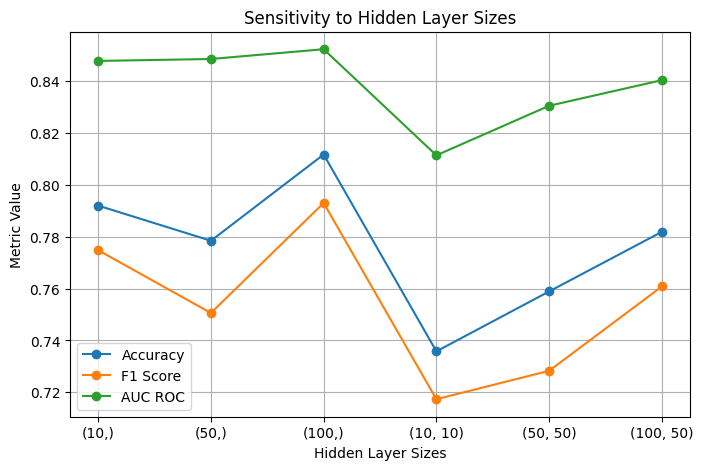

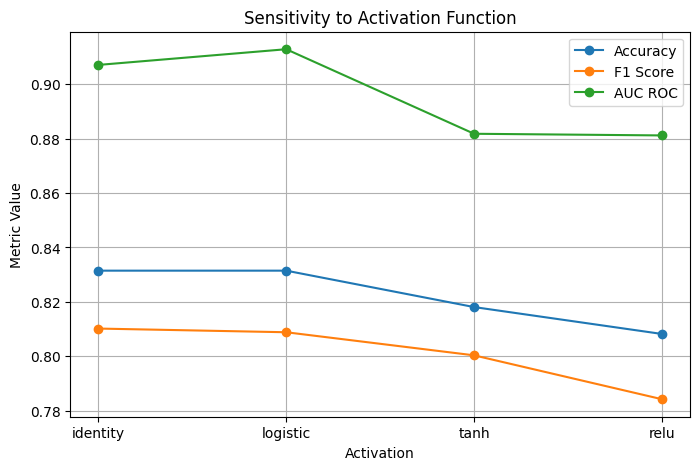

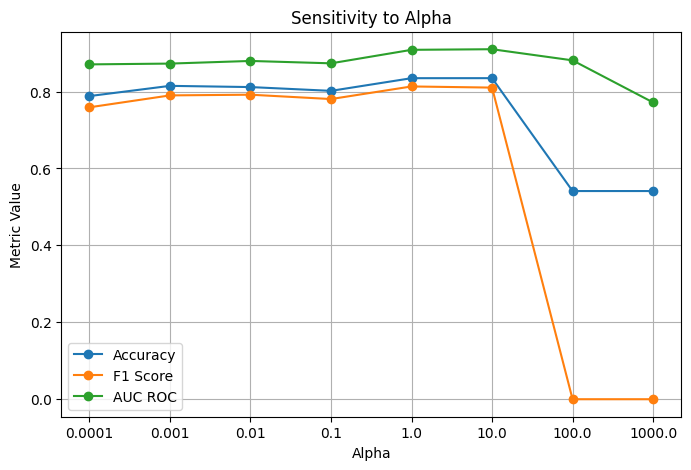

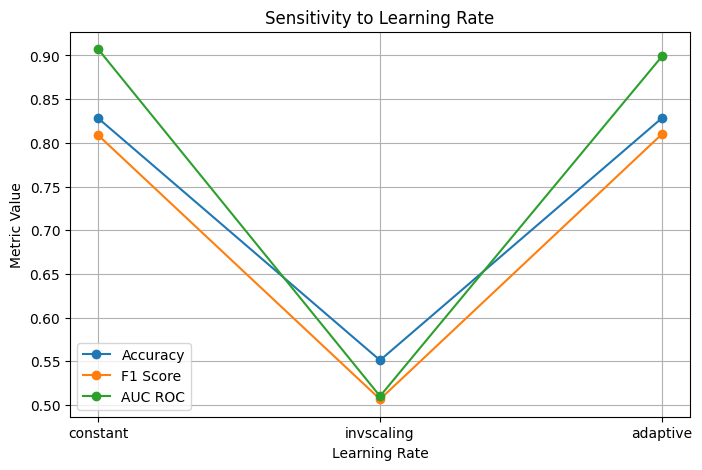

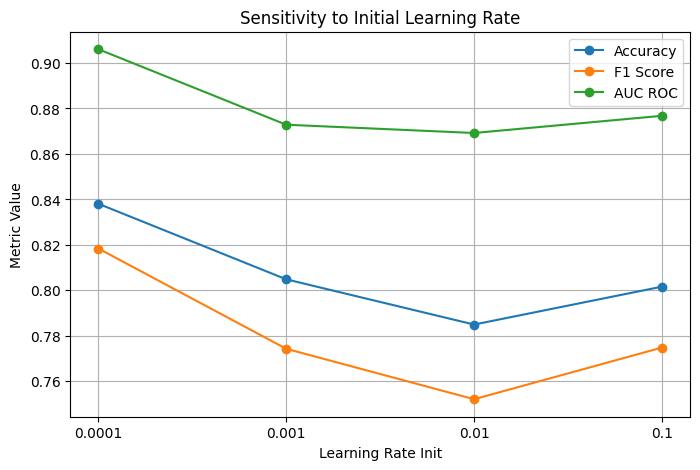

In [ ]:
plot_metrics(df_mlp_hidden, "Hidden Layer Sizes", "Sensitivity to Hidden Layer Sizes")
plot_metrics(df_mlp_activation, "Activation", "Sensitivity to Activation Function")
plot_metrics(df_mlp_alpha, "Alpha", "Sensitivity to Alpha")
plot_metrics(df_mlp_learning_rate, "Learning Rate", "Sensitivity to Learning Rate")
plot_metrics(df_mlp_learning_rate_init, "Learning Rate Init", "Sensitivity to Initial Learning Rate")